In [27]:
import math
import os
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import graph_tool.all as gt

### 1) Load data and map chromatin regions

In [2]:
file='mESC_WT_chr3_3Mb_4DNFIA63SK83.csv'
fin='.'.join(file.split('.')[:-1])

df=pd.read_csv(f'orca_data/mESC/{file}',skiprows=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],header=None)
df.head()

,0,1,2,3,4,5,6,7,8
0,1,1,1658.008338,1759.549715,6646.495704,chr3,33300001,33330001,90
1,2,1,1891.425386,1274.138668,7023.458771,chr3,33330002,33360002,90
2,3,1,1944.000000,1437.109841,6756.559912,chr3,33360003,33390003,90
3,4,1,1069.024893,1434.096046,6807.127340,chr3,33390004,33420004,90
4,5,1,1383.506876,1864.879658,6598.991923,chr3,33420005,33450005,90


In [3]:
df.columns=['spot_id','trace_id','x','y','z','chrom','start','end','cell_id']
df['code']=df['chrom']+'-'+df['start'].astype(str)+'-'+df['end'].astype(str)
df['code_id']=df['chrom']+'-'+df['start'].astype(str)+'-'+df['end'].astype(str)+'-'+df['trace_id'].astype(str)

nodes=pd.DataFrame()
nodes['n']=sorted(list(set(df['start'])))
nodes.index=[x for x in range(nodes.shape[0])]

n_to_code = {n: i for i, n in enumerate(nodes['n'])}
nodes['codes']=n_to_code.values()

df['code'] = df['start'].map(n_to_code)
df.head()

,spot_id,trace_id,x,y,z,chrom,start,end,cell_id,code,code_id
0,1,1,1658.008338,1759.549715,6646.495704,chr3,33300001,33330001,90,0,chr3-33300001-33330001-1
1,2,1,1891.425386,1274.138668,7023.458771,chr3,33330002,33360002,90,1,chr3-33330002-33360002-1
2,3,1,1944.000000,1437.109841,6756.559912,chr3,33360003,33390003,90,2,chr3-33360003-33390003-1
3,4,1,1069.024893,1434.096046,6807.127340,chr3,33390004,33420004,90,3,chr3-33390004-33420004-1
4,5,1,1383.506876,1864.879658,6598.991923,chr3,33420005,33450005,90,4,chr3-33420005-33450005-1


### 2) Build the distance matrix

In [ ]:
dist=np.zeros((df['trace_id'].max(),df['code'].max(),df['code'].max()))
dist[:] = np.nan
print('dist: '+str(df['trace_id'].max()))
print(' ')
for i in sorted(list(set(df['trace_id']))):
    df1=df[df['trace_id']==i]
    for r1 in df1['code']:
        #c1=df1['code'].tolist()[r1]
        p1=df1[df1['code']==r1][['x','y','z']].iloc[0,:].tolist()
        for r2 in df1['code']:
            #c2=df1['code'].tolist()[r2]
            p2=df1[df1['code']==r2][['x','y','z']].iloc[0,:].tolist()
            dist[i-1,r1-1,r2-1]=math.dist(p1,p2)
            dist[i-1,r2-1,r1-1]=math.dist(p1,p2)

### 3) Count only chromatin region pairs closer than 256nm

In [6]:
thr=256
above_threshold=dist<thr
count_above_threshold = np.sum(above_threshold, axis=0)

<Axes: >

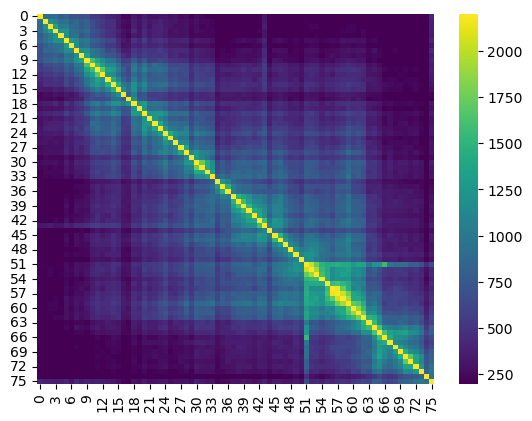

In [25]:
count_above_threshold=dist
sns.heatmap(count_above_threshold,cmap='viridis',vmax=2200,vmin=200)

### 4) Network generation

In [28]:
### PROCESSING MATRIX ###
CV1=count_above_threshold
rows, cols = np.where(CV1 != 0)  # Consider all non-zero values
weights = CV1[rows, cols]
CV = pd.DataFrame([rows,cols,weights]).T
CV.columns=['v1','v2','weight']
CV['v1']=CV['v1'].astype(int)
CV['v2']=CV['v2'].astype(int)

# Remove self loops
CV=CV[CV['v1']!=CV['v2']]

# Remove duplicate edges for an undirected graph
CV['min_node'] = CV[['v1', 'v2']].min(axis=1)
CV['max_node'] = CV[['v1', 'v2']].max(axis=1)
# Keep only unique edges
undirected_edges_df = CV.drop_duplicates(subset=['min_node', 'max_node'])[['min_node', 'max_node', 'weight']]
undirected_edges_df.columns = ['v1', 'v2', 'weight']


### GRAPH GENERATION ###

g = gt.Graph(directed=False)
for i in range(undirected_edges_df.shape[0]):
    g.add_edge(undirected_edges_df.iloc[i,0],undirected_edges_df.iloc[i,1])

#add weights as an edge propetyMap
ew = g.new_edge_property("double")
ew.a = undirected_edges_df['weight'] 
g.ep['edge_weight'] = ew


### 5) uncertain reconstruction

In [ ]:
n=g.new_ep("int",val=g.ep['edge_weight'].a.max())
n_default=g.ep['edge_weight'].a.max()
x=g.new_edge_property("int",vals=g.ep['edge_weight'].a)
x_default=0

state = gt.MixedMeasuredBlockState(g, n=n, n_default=n_default, x=x, x_default=x_default)


# We will first equilibrate the Markov chain
gt.mcmc_equilibrate(state, wait=1000, mcmc_args=dict(niter=10))



# Now we collect the marginals for exactly 100,000 sweeps, at
# intervals of 10 sweeps:
u = None              # marginal posterior edge probabilities
bs = []               # partitions
cs = []               # average local clustering coefficient

def collect_marginals(s):
   global bs, u, cs
   u = s.collect_marginal(u)
   bstate = s.get_block_state()
   bs.append(bstate.levels[0].b.a.copy())
   cs.append(gt.local_clustering(s.get_graph()).fa.mean())

gt.mcmc_equilibrate(state, force_niter=10000, mcmc_args=dict(niter=10),
                    callback=collect_marginals)


### OBTAIN DATA ###

# Disambiguate partitions and obtain marginals
pmode = gt.PartitionModeState(bs, converge=True)
pv = pmode.get_marginal(u)
pv=[x for x in pv]


### 6) Visualization

<Axes: >

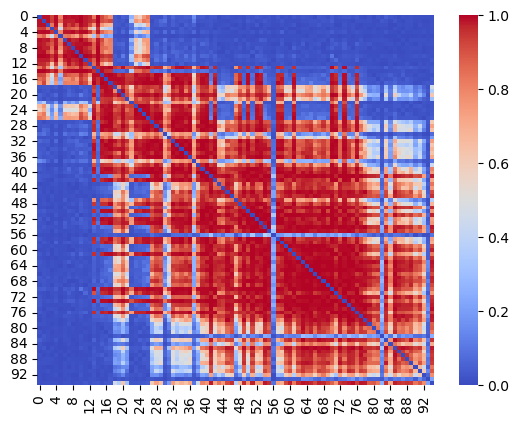

In [38]:
ue=[]
for e in u.iter_edges():
    ue.append(e)
len(ue)

eprob=[]
for e in ue:
    eprob.append(u.ep.eprob[e])

probs=pd.DataFrame([sorted(x) for x in ue],columns=['start','end'])

n_nodes = probs[['start','end']].max().max()+1
A = np.zeros((n_nodes,n_nodes))

for ic in range(probs.shape[0]):
    i = int(probs.iloc[ic,0])
    j = int(probs.iloc[ic,1])
    weight = eprob[ic]
    A[i,j] = weight
    A[j,i] = weight
sns.heatmap(A,cmap='coolwarm')